# Итоговая работа.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import differential_evolution
from scipy.optimize import minimize
from scipy.stats import norm
%matplotlib inline

## Задание 1


Вычислите производную функции: 

$tg^2(sin(x) + cos(2x+3))$ 

в точке $x_0=1$


In [2]:
import sympy as sp
x_symbol = sp.symbols('x',real=True)
expression = sp.tan(sp.sin(x_symbol)+sp.cos(2*x_symbol+3))**2
derivative = sp.diff(expression,x_symbol)
display(derivative)
print('Производная при x=1:',sp.N(derivative.subs(x_symbol,1),12))
fn = sp.lambdify(x_symbol,expression,'numpy')
h=1e-6
assert np.isclose(float(derivative.subs(x_symbol,1)),(fn(1+h)-fn(1-h))/(2*h),rtol=1e-5)

2*(-2*sin(2*x + 3) + cos(x))*(tan(sin(x) + cos(2*x + 3))**2 + 1)*tan(sin(x) + cos(2*x + 3))

Производная при x=1: 55.3859176353


## Задание 2

Дан объект в $2D$ пространстве

(-200.0, 200.0)

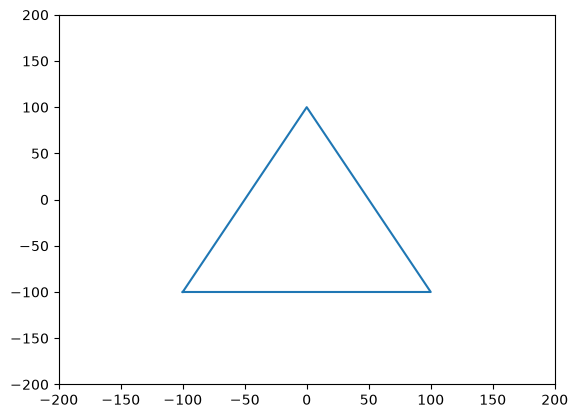

In [3]:
import numpy as np
import matplotlib.pyplot as plt

A = [
[-100, -100, 1],
[0, 100, 1],
[100, -100, 1],
[-100, -100, 1]
]

A = np.array(A)

x = A[:,0]
y = A[:,1]
plt.plot(x, y)
plt.ylim([-200, 200])
plt.xlim([-200, 200]) 

При помощи матричных операций выполните:
- Масштабирование и смещение объекта (применить 2 матрицы трансформаций). Масштабирование на (0.5, 1.2) и смещение на (200, 300)


Преобразованные точки: [[150. 180.   1.]
 [200. 420.   1.]
 [250. 180.   1.]
 [150. 180.   1.]]


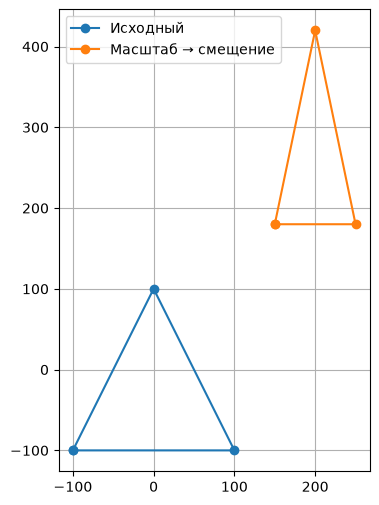

In [4]:
S = np.diag([0.5,1.2,1])
T = np.array([[1,0,200],[0,1,300],[0,0,1]])
scaled = A @ S.T
transformed = scaled @ T.T
assert np.allclose(transformed[:,:2],A[:,:2]*[0.5,1.2]+[200,300])
print('Преобразованные точки:',transformed)
fig,ax = plt.subplots(figsize=(8,6))
for points,title in [(A,'Исходный'),(transformed,'Масштаб → смещение')]:
    ax.plot(points[:,0],points[:,1],marker='o',label=title)
ax.set_aspect('equal'); ax.legend(); ax.grid(); plt.show()

## Задание 3


Найдите собственные значения и собственные вектора матрицы:

In [5]:
m = np.array([[1, 4],
              [1, 1]])
print(m)

[[1 4]
 [1 1]]


In [6]:
values,vectors = np.linalg.eig(m)
assert np.allclose(np.sort(values),[-1,3])
assert np.allclose(m @ vectors,vectors @ np.diag(values))
print('Собственные значения:',values,'\nВекторы — столбцы:',vectors)

Собственные значения: [ 3.+0.j -1.+0.j] 
Векторы — столбцы: [[ 0.89442719+0.j -0.89442719+0.j]
 [ 0.4472136 +0.j  0.4472136 +0.j]]


## Задание 4


Дана функция с неизвестными параметрами a и b, вам также известны значения функции `fx` в точках `x`. 

Найдите оптимальные параметры a, b, минимизирующие абсолютную ошибку `error`.


In [7]:
def f(x, a, b):
    return np.e**a * np.sin(b*x) + x

In [8]:
x = np.array([0.        , 0.26315789, 0.52631579, 0.78947368, 1.05263158,
              1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105,
              2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053,
              3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.        ])

fx = np.array([  0.        , -12.01819092, -18.90968634, -17.68786571,
                -8.7529108 ,   4.27524517,  16.06801336,  21.81250213,
                19.22059845,   9.48411207,  -3.22273056, -13.48576488,
               -16.91096359, -11.95866834,  -0.58630088,  12.56873816,
                22.12489421,  24.20292139,  18.04522521,   6.33211092])

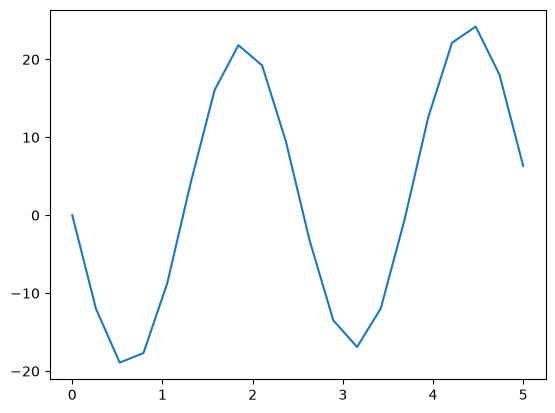

In [9]:
plt.plot(x, fx)
plt.show()

In [10]:
def error(params):
    return np.sum(np.abs(fx - f(x, params[0], params[1])))

a, b: [ 3.  -2.5] ; сумма абсолютных ошибок: 1.5099511800897858e-06


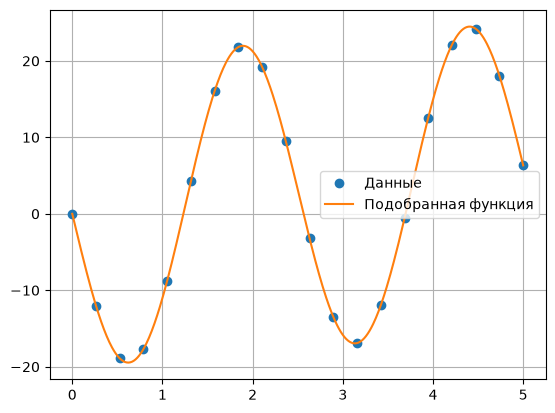

In [11]:
# Границы — явно выбранная область поиска, не доказательство глобального
# минимума по неограниченной частоте b. Отрицательная b нужна для этих данных.
search_bounds = [(-5,5),(-10,10)]
global_result = differential_evolution(error,search_bounds,seed=42,tol=1e-9,maxiter=1500,polish=False)
local_result = minimize(error,global_result.x,method='Nelder-Mead',options={'xatol':1e-11,'fatol':1e-10,'maxiter':5000})
best = min([global_result,local_result],key=lambda r:r.fun)
print('a, b:',best.x,'; сумма абсолютных ошибок:',best.fun)
assert best.fun < 1e-4
plt.plot(x,fx,'o',label='Данные')
grid = np.linspace(0,5,500)
plt.plot(grid,f(grid,*best.x),label='Подобранная функция')
plt.legend(); plt.grid(); plt.show()

## Задание 5



Дана матрица рейтингов фильмов (строки - пользователи (10 человек), столбцы - фильмы (15 фильмов))

In [12]:
raitings = np.array([[ 4,  4,  9,  4,  1,  6, 10,  7,  9,  6,  9,  2,  8,  6,  6],
                     [ 9,  2,  5, 10,  7,  8, 10,  5,  6,  2,  1,  6,  8,  9,  7],
                     [ 1,  6,  8,  8,  4,  9,  3,  8, 10,  5,  2,  6,  8,  1,  6],
                     [ 6,  1,  9,  7,  7,  9,  2,  3,  5,  1,  6,  6,  3,  2,  7],
                     [ 3,  7,  3,  5,  7,  9,  9,  6,  2,  9,  1,  2,  8, 10,  6],
                     [ 8,  3,  7,  3,  8,  6,  1,  8,  8,  6,  1,  9,  4, 10,  1],
                     [ 9,  8,  4,  8,  8, 10,  6,  1,  1,  2,  9,  5,  2,  7,  2],
                     [ 4,  1,  6,  4,  3, 10,  4,  4,  2,  8,  7,  9,  3,  8,  3],
                     [ 2,  7,  7,  6, 10,  6,  8,  9,  8,  6, 10,  1,  7, 10,  4],
                     [ 5, 10,  8,  8,  9,  7,  2,  9,  9, 10,  8,  8,  8,  6, 10]])

Необходимо найти наиболее похожего пользователя по косинусной метрике для каждого из пользователей (ответ: 10 пар вида (x, y), где y - наиболее похожий пользователь на пользователя x).

In [13]:
norms = np.linalg.norm(raitings,axis=1)
similarity = (raitings @ raitings.T)/np.outer(norms,norms)
np.fill_diagonal(similarity,-np.inf)
nearest = np.argmax(similarity,axis=1)
assert np.all(nearest != np.arange(len(raitings)))
assert len(nearest)==10
for user,neighbor in enumerate(nearest):
    print(f'({user+1}, {neighbor+1}), cosine={similarity[user,neighbor]:.6f}')

(1, 9), cosine=0.910660
(2, 5), cosine=0.871381
(3, 10), cosine=0.918731
(4, 10), cosine=0.858869
(5, 9), cosine=0.879485
(6, 10), cosine=0.855149
(7, 4), cosine=0.832742
(8, 6), cosine=0.844517
(9, 1), cosine=0.910660
(10, 3), cosine=0.918731


## Решение и проверка

Решение подготовлено AI по запросу владельца репозитория. Выполнение подтверждает работоспособность кода; самостоятельное владение материалом не оценивалось.

Пользователи нумеруются с 1. Сравнение пользователя с самим собой исключено. При равенстве максимальных оценок выбирается первый индекс.

Собственные значения матрицы: −1 и 3; направления векторов (−2, 1) и (2, 1).